# 02 · Feature visual checks — does each function do what we think?

Unit tests prove the functions are **correct on toy data**. This notebook shows what
they **produce on a real race** (2023 Bahrain GP), one function per section, so you
can sanity-check the numbers with your eyes and F1 intuition.

Each section has a **"What to look for"** box — if a plot doesn't match it, something is off.

> Run `pytest tests/test_features.py` first. If a function still raises
> `NotImplementedError` or fails tests, its section here will error too.

In [1]:
# Run from the repo root so `import src...` works and FastF1 uses data/cache/.
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

import importlib
import logging

import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.features.build_features as bf
importlib.reload(bf)  # re-run this cell after editing build_features.py
from src.data.ingestion import build_lap_dataset, dataset_path, load_laps_parquet, load_session

fastf1.set_log_level("ERROR")
logging.getLogger("fastf1").setLevel(logging.ERROR)
pd.set_option("display.max_columns", 40, "display.width", 200)

plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 2,
    "legend.frameon": False,
})
DRIVER_COLORS = {"VER": "#2a78d6", "HAM": "#eb6834", "ALO": "#1baf7a"}
COMPOUND_COLORS = {"SOFT": "#e34948", "MEDIUM": "#eda100", "HARD": "#8a8984"}
STINT_STYLES = ["-", "--", ":", "-."]
LOSS, GAIN, NEUTRAL = "#e34948", "#2a78d6", "#8a8984"

In [2]:
# The real Phase 1 -> Phase 2 path: Parquet on disk -> build_features.
YEAR, EVENT, TOTAL_LAPS = 2023, "Bahrain Grand Prix", 57
path = dataset_path(YEAR, EVENT, "R")
if not path.exists():
    build_lap_dataset(YEAR, "Bahrain", "R")
laps = load_laps_parquet(path)
features = bf.build_features(laps, total_laps=TOTAL_LAPS)
print(f"raw laps: {len(laps)}  ->  feature rows: {len(features)}")
features[["Driver", "LapNumber", "Stint", "Compound", "TyreLife", bf.TARGET_COLUMN,
          "FuelCorrectedLapTime_s", "RollingPace_s", "TireDegIndex_s_per_lap",
          "TrackTempDelta_C", "DownforceIndex"]].query("Driver == 'VER'").head(12)

raw laps: 1056  ->  feature rows: 889


,Driver,LapNumber,Stint,Compound,TyreLife,LapTime_s,FuelCorrectedLapTime_s,RollingPace_s,TireDegIndex_s_per_lap,TrackTempDelta_C,DownforceIndex
794,VER,3,1,SOFT,6.0,98.006,94.766,NaN,NaN,-0.2,0.959643
795,VER,4,1,SOFT,7.0,97.976,94.796,94.766000,NaN,-0.1,0.959454
796,VER,5,1,SOFT,8.0,98.035,94.915,94.781000,NaN,-0.2,0.959980
797,VER,6,1,SOFT,9.0,97.986,94.926,94.825667,0.0745,-0.3,0.959980
798,VER,7,1,SOFT,10.0,98.021,95.021,94.850750,0.0599,-0.3,0.960316
799,VER,8,1,SOFT,11.0,98.154,95.214,94.884800,0.0640,-0.4,0.960444
800,VER,9,1,SOFT,12.0,98.278,95.398,94.974400,0.0942,-0.4,0.960444
801,VER,10,1,SOFT,13.0,98.369,95.549,95.094800,0.1254,-0.5,0.960109
802,VER,11,1,SOFT,14.0,98.483,95.723,95.221600,0.1623,-0.5,0.960444
803,VER,12,1,SOFT,15.0,98.591,95.891,95.381000,0.1739,-0.7,0.960109


## 1 · `fuel_corrected_lap_time` — removing the fuel effect

Left: one driver's raw vs corrected lap times over the race. Right: the gap between them.

**What to look for**
* The gap is a **straight line**: 0.06 × 56 ≈ 3.4 s on lap 1, shrinking to 0 on lap 57.
* Corrected times are always ≤ raw times, and equal on the last lap.
* Within each stint, the corrected line tilts **more upward** than the raw one — that's the
  degradation fuel burn was hiding.

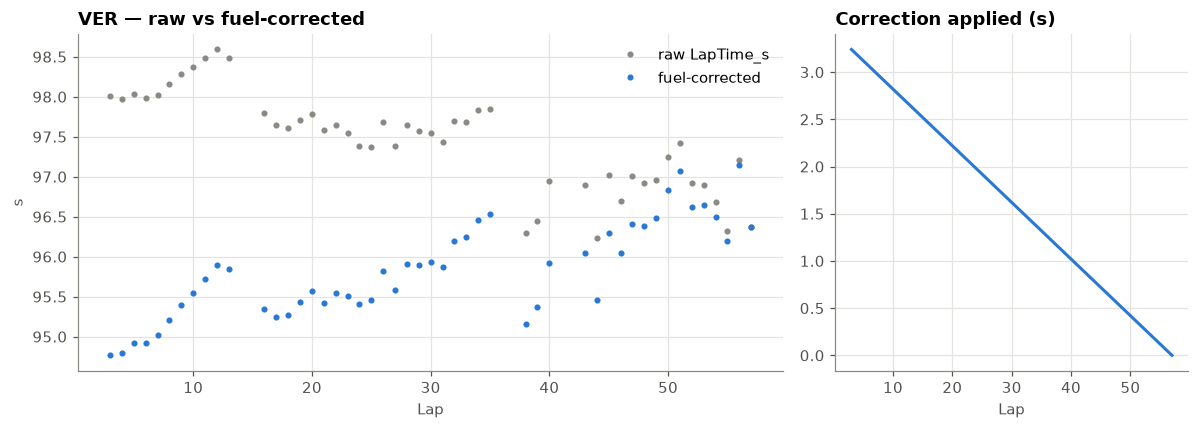

In [3]:
d = features[features["Driver"] == "VER"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), width_ratios=[2, 1])
axes[0].plot(d["LapNumber"], d[bf.TARGET_COLUMN], ".", color=NEUTRAL, label="raw LapTime_s")
axes[0].plot(d["LapNumber"], d["FuelCorrectedLapTime_s"], ".", color=GAIN, label="fuel-corrected")
axes[0].set_xlabel("Lap"); axes[0].set_ylabel("s"); axes[0].legend()
axes[0].set_title("VER — raw vs fuel-corrected", loc="left")
axes[1].plot(d["LapNumber"], d[bf.TARGET_COLUMN] - d["FuelCorrectedLapTime_s"], color=GAIN)
axes[1].set_xlabel("Lap"); axes[1].set_title("Correction applied (s)", loc="left")
plt.tight_layout()

In [4]:
# Per-stint slope before vs after correction (plain OLS over the whole stint, for intuition only).
def stint_slopes(df, col):
    return (df.groupby(["Driver", "Stint"], observed=True)
              .apply(lambda g: np.polyfit(g["TyreLife"], g[col], 1)[0] if len(g) >= 5 else np.nan,
                     include_groups=False))

slopes = pd.DataFrame({
    "raw_s_per_lap": stint_slopes(features, bf.TARGET_COLUMN),
    "corrected_s_per_lap": stint_slopes(features, "FuelCorrectedLapTime_s"),
}).dropna()
slopes["difference"] = slopes["corrected_s_per_lap"] - slopes["raw_s_per_lap"]
print("Every difference should be ≈ +0.06 (the fuel effect per lap):")
slopes.loc[list(DRIVER_COLORS)].round(3)

Every difference should be ≈ +0.06 (the fuel effect per lap):


raw_s_per_lap  corrected_s_per_lap  difference
Driver Stint                                                
VER    1              0.066                0.126        0.06
       2              0.001                0.061        0.06
       3              0.013                0.073        0.06
HAM    1              0.198                0.258        0.06
       2             -0.019                0.041        0.06
       3              0.033                0.093        0.06
ALO    1              0.162                0.222        0.06
       2              0.002                0.062        0.06
       3              0.024                0.084        0.06

## 2 · `lagged_rolling_mean` — `RollingPace_s`

Dots are each lap's fuel-corrected time; the line is `RollingPace_s` on the same row.

**What to look for**
* The line **trails** the dots (it's built from previous laps only). A line that hugs
  each dot exactly would mean the current lap leaked in.
* The line **restarts** after every pit stop (first lap of each stint = NaN, no line).
* A one-off slow lap (traffic, mistake) bumps the line on the **next** laps, not its own.

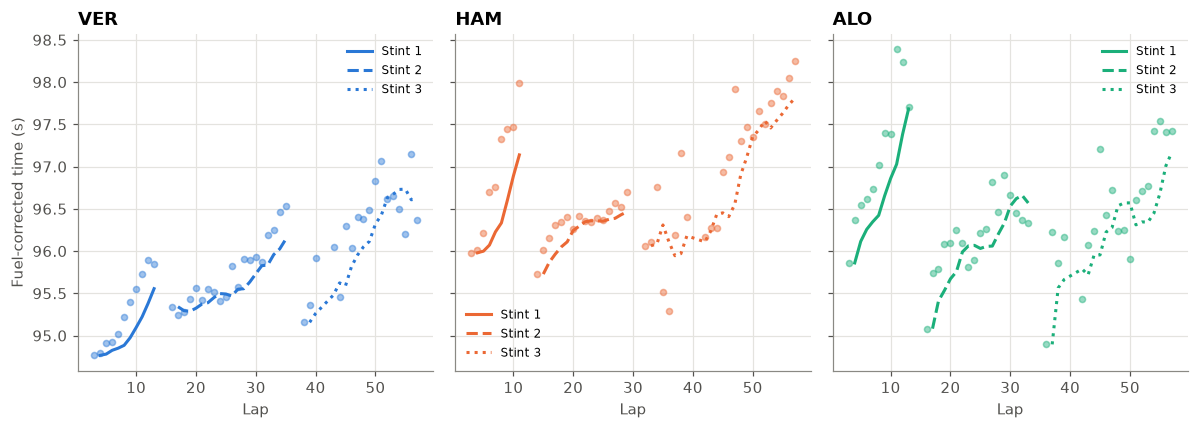

In [5]:
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(11, 4))
for ax, (drv, color) in zip(axes, DRIVER_COLORS.items()):
    d = features[features["Driver"] == drv]
    for i, (stint, g) in enumerate(d.groupby("Stint", observed=True)):
        ax.plot(g["LapNumber"], g["FuelCorrectedLapTime_s"], "o", markersize=4, color=color, alpha=0.45)
        ax.plot(g["LapNumber"], g["RollingPace_s"], color=color, linestyle=STINT_STYLES[i % 4],
                label=f"Stint {int(stint)}")
    ax.set_title(drv, loc="left"); ax.set_xlabel("Lap"); ax.legend(fontsize=8)
axes[0].set_ylabel("Fuel-corrected time (s)")
plt.tight_layout()

In [6]:
# The leakage check, as a table: RollingPace_s on row t == mean of the previous `window` corrected times.
g = features[(features["Driver"] == "VER") & (features["Stint"] == 1)][
    ["LapNumber", "FuelCorrectedLapTime_s", "RollingPace_s"]].head(8).copy()
g["manual_prev5_mean"] = g["FuelCorrectedLapTime_s"].shift(1).rolling(5, min_periods=1).mean()
g.round(3)

,LapNumber,FuelCorrectedLapTime_s,RollingPace_s,manual_prev5_mean
794,3,94.766,NaN,NaN
795,4,94.796,94.766,94.766
796,5,94.915,94.781,94.781
797,6,94.926,94.826,94.826
798,7,95.021,94.851,94.851
799,8,95.214,94.885,94.885
800,9,95.398,94.974,94.974
801,10,95.549,95.095,95.095


## 3 · `tire_degradation_index` — rolling slope of pace vs tyre age

### 3a · Does it recover a known slope from noisy data?
Synthetic stint with a **true** degradation of 0.08 s/lap plus realistic lap-to-lap noise.

**What to look for**
* Estimates scatter **around** the dashed true value, not systematically above/below.
* Bigger windows → less scatter (less variance) — the bias–variance trade-off.

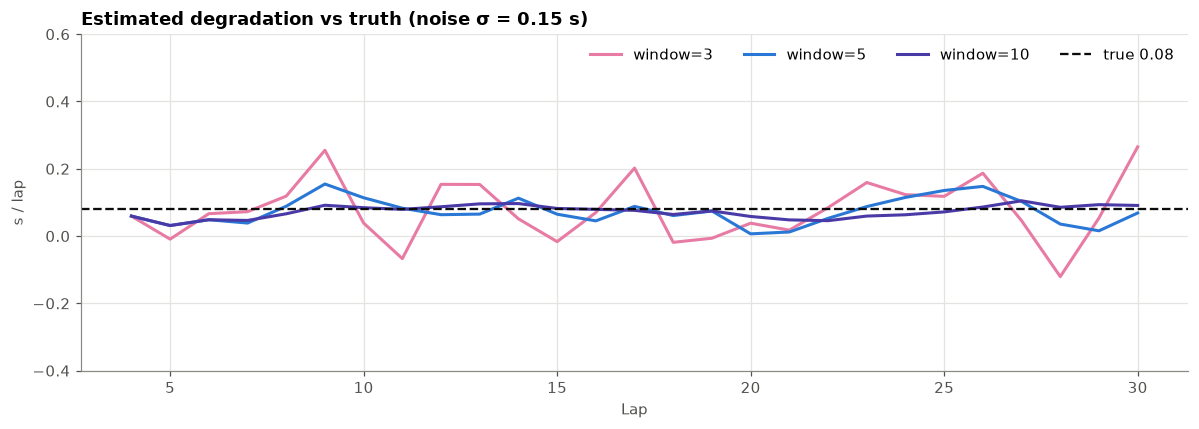

In [7]:
rng = np.random.default_rng(7)
n, true_deg = 30, 0.08
life = np.arange(1, n + 1, dtype=float)
synthetic = pd.DataFrame({
    "Driver": "SYN", "Stint": 1, "LapNumber": np.arange(1, n + 1), "TyreLife": life,
    "FuelCorrectedLapTime_s": 95 + true_deg * life + rng.normal(0, 0.15, n),
})

fig, ax = plt.subplots()
for w, color in zip([3, 5, 10], ["#e87ba4", "#2a78d6", "#4a3aa7"]):
    est = bf.tire_degradation_index(synthetic, window=w, min_periods=min(3, w))
    ax.plot(synthetic["LapNumber"], est, color=color, label=f"window={w}")
ax.axhline(true_deg, color="#0b0b0b", linestyle="--", linewidth=1.5, label="true 0.08")
ax.set_ylim(-0.4, 0.6); ax.set_xlabel("Lap"); ax.set_ylabel("s / lap")
ax.set_title("Estimated degradation vs truth (noise σ = 0.15 s)", loc="left"); ax.legend(ncol=4)
plt.tight_layout()

### 3b · On the real race

**What to look for**
* Values mostly in roughly **−0.2 … +0.4 s/lap**. Long HARD stints are noisier: lap-to-lap
  variation (traffic, battery deployment) is large compared with their small true degradation.
* SOFT stints should degrade faster (higher index) than HARD stints.
* NaN for the first `min_periods` laps of every stint.

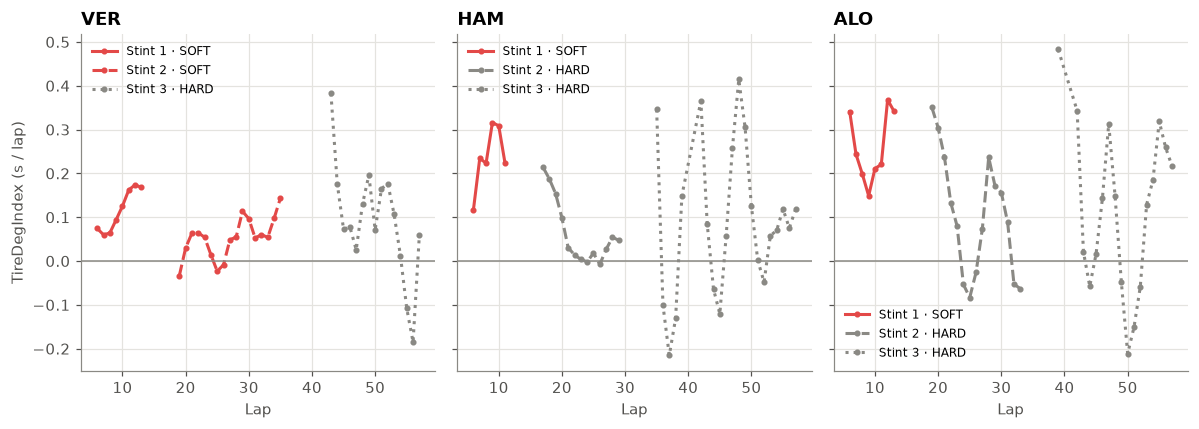

In [8]:
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(11, 4))
for ax, (drv, color) in zip(axes, DRIVER_COLORS.items()):
    d = features[features["Driver"] == drv]
    for i, (stint, g) in enumerate(d.groupby("Stint", observed=True)):
        comp = str(g["Compound"].iloc[0])
        ax.plot(g["LapNumber"], g["TireDegIndex_s_per_lap"], color=COMPOUND_COLORS.get(comp, NEUTRAL),
                linestyle=STINT_STYLES[i % 4], marker="o", markersize=3, label=f"Stint {int(stint)} · {comp}")
    ax.axhline(0, color=NEUTRAL, linewidth=1)
    ax.set_title(drv, loc="left"); ax.set_xlabel("Lap"); ax.legend(fontsize=8)
axes[0].set_ylabel("TireDegIndex (s / lap)")
plt.tight_layout()

,count,mean,std,min,25%,50%,75%,max
Compound,,,,,,,,
HARD,407.0,0.105,0.145,-0.392,0.030,0.097,0.176,0.632
MEDIUM,5.0,0.198,0.119,0.068,0.112,0.163,0.314,0.332
SOFT,274.0,0.163,0.204,-1.569,0.092,0.180,0.259,0.878


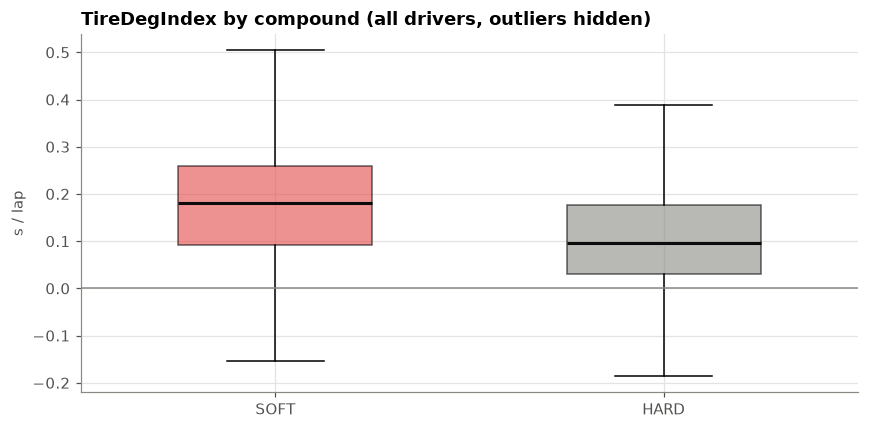

In [9]:
deg = features.dropna(subset=["TireDegIndex_s_per_lap"])
comps = [c for c in ["SOFT", "MEDIUM", "HARD"] if (deg["Compound"] == c).sum() >= 50]
fig, ax = plt.subplots(figsize=(8, 4))
data = [deg.loc[deg["Compound"] == c, "TireDegIndex_s_per_lap"].clip(-1, 1) for c in comps]
bp = ax.boxplot(data, tick_labels=comps, patch_artist=True, widths=0.5, showfliers=False,
                medianprops={"color": "#0b0b0b", "linewidth": 2})
for patch, c in zip(bp["boxes"], comps):
    patch.set_facecolor(COMPOUND_COLORS[c]); patch.set_alpha(0.6)
ax.axhline(0, color=NEUTRAL, linewidth=1)
ax.set_ylabel("s / lap"); ax.set_title("TireDegIndex by compound (all drivers, outliers hidden)", loc="left")
plt.tight_layout()
deg.groupby("Compound", observed=True)["TireDegIndex_s_per_lap"].describe().round(3)

## 4 · `track_temp_delta` — track temperature change since the stint started

**What to look for**
* A **sawtooth**: starts at 0 on every new stint, drifts during the stint, resets at the pit stop.
* Bahrain is a twilight race, so the drift is mostly **downward** (track cooling).

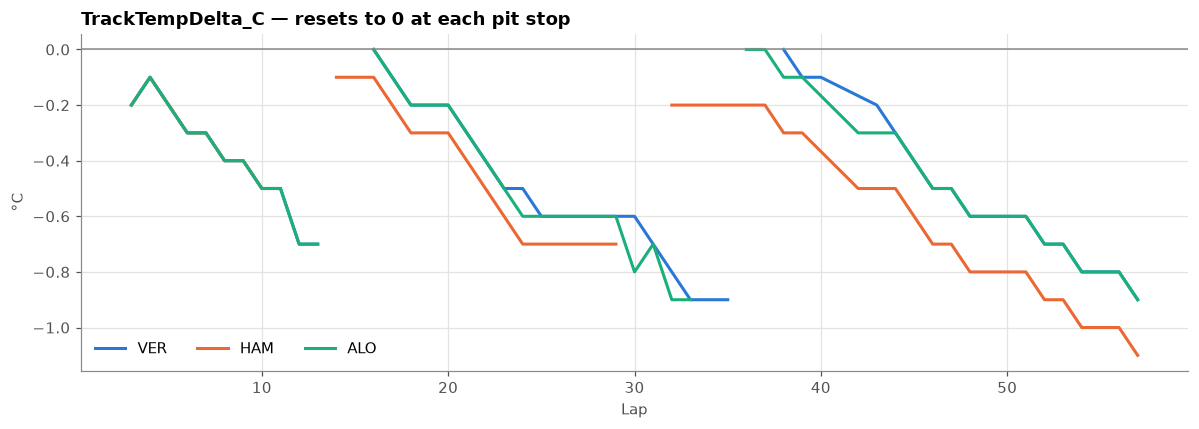

In [10]:
fig, ax = plt.subplots()
for drv, color in DRIVER_COLORS.items():
    d = features[features["Driver"] == drv]
    for i, (stint, g) in enumerate(d.groupby("Stint", observed=True)):
        ax.plot(g["LapNumber"], g["TrackTempDelta_C"], color=color, label=drv if i == 0 else None)
ax.axhline(0, color=NEUTRAL, linewidth=1)
ax.set_xlabel("Lap"); ax.set_ylabel("°C")
ax.set_title("TrackTempDelta_C — resets to 0 at each pit stop", loc="left"); ax.legend(ncol=3)
plt.tight_layout()

## 5 · `air_density` / `DownforceIndex`

Left: the physics — density vs air temperature at three humidity levels (sea-level pressure).
Right: what Bahrain actually looked like during the race.

**What to look for**
* Hotter → less dense; more humid → (slightly) less dense. Dry 15 °C hits the ISA dot at 1.225.
* Bahrain sits around **0.95–0.97** of sea-level downforce; the Mexico City marker ~**0.75**.

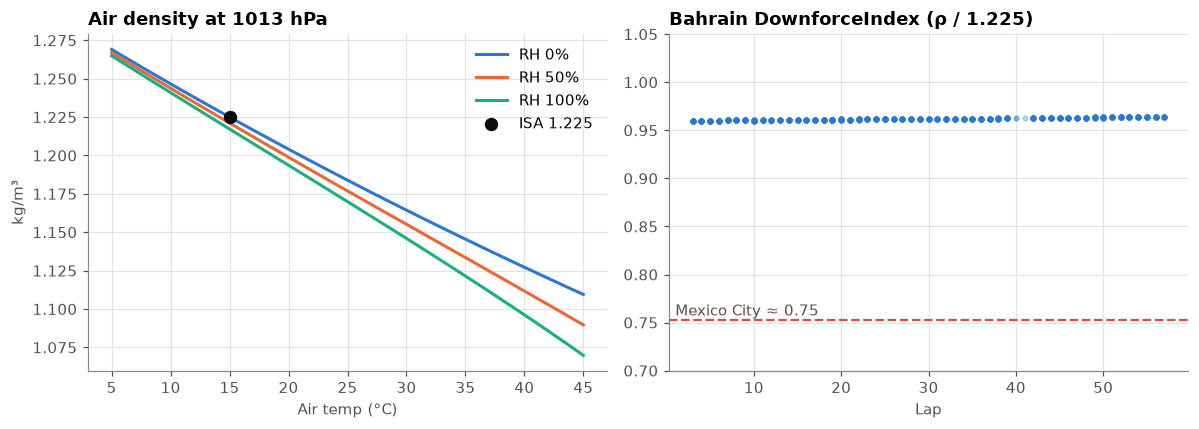

In [11]:
temps = np.linspace(5, 45, 100)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for rh, color in zip([0, 50, 100], ["#2a78d6", "#eb6834", "#1baf7a"]):
    axes[0].plot(temps, bf.air_density(temps, 1013.25, rh), color=color, label=f"RH {rh}%")
axes[0].scatter([15], [bf.RHO_ISA_KG_M3], s=60, color="#0b0b0b", zorder=3, label="ISA 1.225")
axes[0].set_xlabel("Air temp (°C)"); axes[0].set_ylabel("kg/m³"); axes[0].legend()
axes[0].set_title("Air density at 1013 hPa", loc="left")

axes[1].plot(features["LapNumber"], features["DownforceIndex"], ".", color=GAIN, alpha=0.3)
mexico = bf.air_density(20.0, 780.0, 50.0) / bf.RHO_ISA_KG_M3
axes[1].axhline(mexico, color=LOSS, linestyle="--", linewidth=1.5)
axes[1].text(1, mexico + 0.005, f"Mexico City ≈ {mexico:.2f}", color="#52514e")
axes[1].set_ylim(0.7, 1.05); axes[1].set_xlabel("Lap")
axes[1].set_title("Bahrain DownforceIndex (ρ / 1.225)", loc="left")
plt.tight_layout()

## 6 · `micro_sector_deltas` — where on track is time lost?

HAM's fastest lap vs VER's fastest lap (reference), split into 25 equal micro-sectors.
Red = HAM slower there, blue = HAM faster.

**What to look for**
* The bars **sum to the lap-time gap** (checked in the printout).
* Losses cluster where the speed traces in notebook 01 differed (traction zones, long straights).
* The cumulative line ends at the total gap.

sum of micro-sector deltas: +0.388 s   |   official lap-time gap: +0.310 s
(small mismatch is expected: telemetry ends a few metres before/after the line)


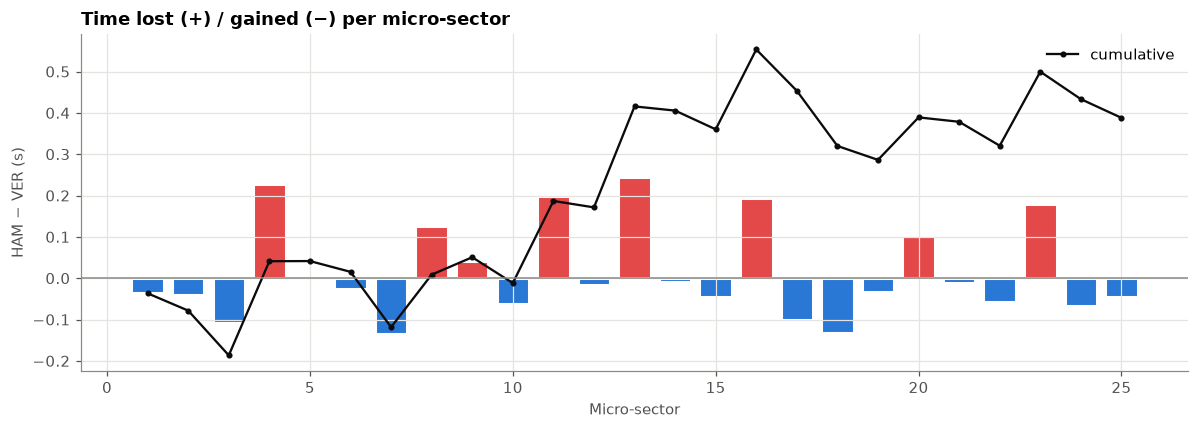

In [12]:
session = load_session(YEAR, "Bahrain", "R", telemetry=True)
ref_lap = session.laps.pick_drivers("VER").pick_fastest()
cmp_lap = session.laps.pick_drivers("HAM").pick_fastest()
ref_tel, cmp_tel = ref_lap.get_telemetry(), cmp_lap.get_telemetry()

N = 25
deltas = bf.micro_sector_deltas(
    cmp_tel["Distance"], cmp_tel["Time"].dt.total_seconds(),
    ref_tel["Distance"], ref_tel["Time"].dt.total_seconds(), n_sectors=N,
)
gap = (cmp_lap["LapTime"] - ref_lap["LapTime"]).total_seconds()
print(f"sum of micro-sector deltas: {deltas.sum():+.3f} s   |   official lap-time gap: {gap:+.3f} s")
print("(small mismatch is expected: telemetry ends a few metres before/after the line)")

fig, ax = plt.subplots()
x = np.arange(1, N + 1)
ax.bar(x, deltas, color=np.where(deltas > 0, LOSS, GAIN), edgecolor="white", linewidth=2)
ax.plot(x, np.cumsum(deltas), color="#0b0b0b", linewidth=1.5, marker="o", markersize=3, label="cumulative")
ax.axhline(0, color=NEUTRAL, linewidth=1)
ax.set_xlabel("Micro-sector"); ax.set_ylabel("HAM − VER (s)"); ax.legend()
ax.set_title("Time lost (+) / gained (−) per micro-sector", loc="left")
plt.tight_layout()

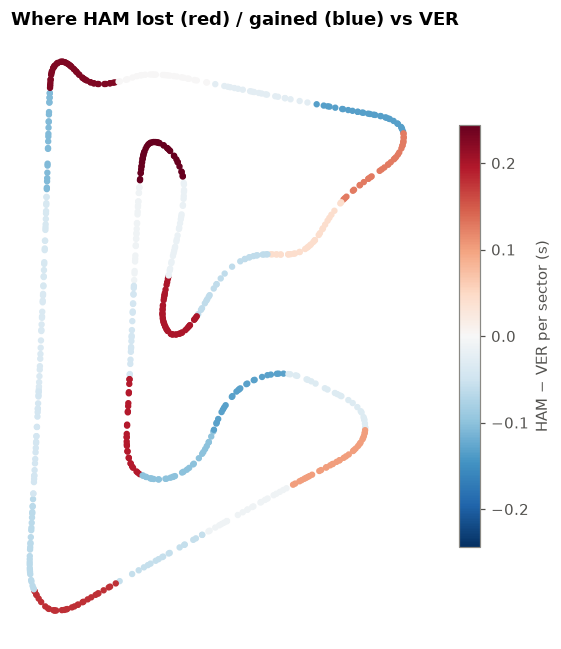

In [13]:
# Same deltas painted onto the track map.
L = min(cmp_tel["Distance"].iloc[-1], ref_tel["Distance"].iloc[-1])
sector_of_sample = np.clip((ref_tel["Distance"] / L * N).astype(int), 0, N - 1)
lim = np.abs(deltas).max()
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(ref_tel["X"], ref_tel["Y"], c=deltas[sector_of_sample], cmap="RdBu_r", vmin=-lim, vmax=lim, s=10)
ax.set_aspect("equal"); ax.axis("off")
fig.colorbar(sc, ax=ax, shrink=0.7, label="HAM − VER per sector (s)")
ax.set_title("Where HAM lost (red) / gained (blue) vs VER", loc="left")
plt.tight_layout()

## 7 · `build_features` — the final feature table

**What to look for**
* Only the pace features have NaNs (the first laps of each stint); weather-based ones are ~0 %.
* `TARGET_COLUMN` and `FuelCorrectedLapTime_s` are **not** in `FEATURE_COLUMNS`.

In [14]:
print("target:", bf.TARGET_COLUMN)
print("features:", bf.FEATURE_COLUMNS)
summary = pd.DataFrame({
    "dtype": features[bf.FEATURE_COLUMNS].dtypes.astype(str),
    "missing_%": (features[bf.FEATURE_COLUMNS].isna().mean() * 100).round(1),
})
numeric = features[bf.FEATURE_COLUMNS].select_dtypes("number")
summary = summary.join(numeric.describe().T[["mean", "std", "min", "max"]].round(3))
summary

target: LapTime_s
features: ['LapNumber', 'TyreLife', 'Compound', 'AirTemp', 'TrackTemp', 'TrackTempDelta_C', 'AirDensity_kgm3', 'DownforceIndex', 'RollingPace_s', 'TireDegIndex_s_per_lap']


,dtype,missing_%,mean,std,min,max
LapNumber,Int16,0.0,28.982002,16.086538,3.0,57.0
TyreLife,float64,0.0,10.335208,5.738493,2.0,29.0
Compound,category,0.0,NaN,NaN,NaN,NaN
AirTemp,float64,0.0,26.737345,0.317082,26.2,27.3
TrackTemp,float64,0.0,29.885489,0.729543,28.7,31.2
TrackTempDelta_C,float64,0.0,-0.397638,0.249244,-1.2,0.0
AirDensity_kgm3,float64,0.0,1.17817,0.001465,1.175331,1.180834
DownforceIndex,float64,0.0,0.961771,0.001196,0.959454,0.963946
RollingPace_s,float64,7.8,96.61078,0.815112,94.168,99.444
TireDegIndex_s_per_lap,float64,22.8,0.128749,0.172974,-1.569,0.878


In [15]:
# Live leakage check on real data: slow down one lap by 10 s and see which features move.
drv, lap = "HAM", 20
leaked = laps.copy()
mask = (leaked["Driver"] == drv) & (leaked["LapNumber"] == lap)
leaked.loc[mask, "LapTime"] += pd.Timedelta(seconds=10)
perturbed = bf.build_features(leaked, total_laps=TOTAL_LAPS)

numeric_cols = [c for c in bf.FEATURE_COLUMNS if c not in ("Compound", "LapNumber")]
d0 = features[features["Driver"] == drv].set_index("LapNumber")[numeric_cols]
d1 = perturbed[perturbed["Driver"] == drv].set_index("LapNumber")[numeric_cols]
changed = ((d0 - d1).abs() > 1e-9).loc[lap - 3: lap + 6]
print(f"True = feature changed after editing {drv} lap {lap}'s time. Laps <= {lap} must be all False.")
changed

True = feature changed after editing HAM lap 20's time. Laps <= 20 must be all False.


/var/folders/75/mq62zp355mv4rk0kysg_k7km0000gn/T/ipykernel_98177/4263381576.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  leaked.loc[mask, "LapTime"] += pd.Timedelta(seconds=10)


,TyreLife,AirTemp,TrackTemp,TrackTempDelta_C,AirDensity_kgm3,DownforceIndex,RollingPace_s,TireDegIndex_s_per_lap
LapNumber,,,,,,,,
17,False,False,False,False,False,False,False,False
18,False,False,False,False,False,False,False,False
19,False,False,False,False,False,False,False,False
20,False,False,False,False,False,False,False,False
21,False,False,False,False,False,False,True,True
22,False,False,False,False,False,False,True,True
23,False,False,False,False,False,False,True,False
24,False,False,False,False,False,False,True,True
25,False,False,False,False,False,False,True,True


## 8 · The whole season - `build_season_features`

Same pipeline, every race file in `data/processed/`. First run builds any missing
Phase 1 files (downloads ~22 races, a few minutes) and writes
`data/features/features_R.parquet`.

**What to look for**
* One row per race in the summary, all ~22 rounds present, ~17–20 drivers each.
* `max_lap` close to each race's real distance (Monaco 78, Spa 44, Austria 71…). It can be
  lower when the final laps ran behind the Safety Car (Australia), because those laps are filtered out.
* DownforceIndex: Mexico City clearly lowest (~0.74), the rest ~0.9–1.0.

In [33]:
from src.data.season import build_season
from src.features.season_features import FEATURES_DIR, build_season_features

build_season(YEAR)  # Phase 1: skips races already in data/processed/
season_path = build_season_features()
season = pd.read_parquet(season_path)
print(season_path, season.shape)

# Calendar order for plots (RaceId sorts alphabetically otherwise).
schedule = fastf1.get_event_schedule(YEAR, include_testing=False)
round_of = {dataset_path(YEAR, name, "R").stem.removesuffix("_R"): rnd
            for name, rnd in zip(schedule["EventName"], schedule["RoundNumber"])}
season["Round"] = season["RaceId"].map(round_of)
season.head()

/Users/konwas/Documents/programming/_pitwall-ml/pitwall-ml/data/features/features_R.parquet (20722, 30)


,Driver,Team,LapNumber,LapStartTime,LapTime,Stint,Compound,TyreLife,PitInTime,PitOutTime,TrackStatus,IsAccurate,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,TrackTempDelta_C,AirDensity_kgm3,DownforceIndex,LapTime_s,FuelCorrectedLapTime_s,RollingPace_s,TireDegIndex_s_per_lap,Year,Event,Session,RaceId,Round
0,ALB,Williams,1,0 days 01:02:24.519000,0 days 00:01:40.625000,1,MEDIUM,2.0,NaT,NaT,1,False,27.0,49.0,1014.9,False,33.6,309,2.2,0.0,1.170255,0.955310,100.625,97.205,NaN,NaN,2023,abu_dhabi,R,2023_abu_dhabi,22
1,ALB,Williams,2,0 days 01:04:05.400000,0 days 00:01:33.560000,1,MEDIUM,3.0,NaT,NaT,1,True,27.1,49.0,1014.7,False,33.6,345,2.0,0.0,1.169588,0.954766,93.560,90.200,97.205000,NaN,2023,abu_dhabi,R,2023_abu_dhabi,22
2,ALB,Williams,3,0 days 01:05:38.960000,0 days 00:01:31.768000,1,MEDIUM,4.0,NaT,NaT,1,True,27.0,51.0,1014.9,False,33.4,359,1.7,-0.2,1.169942,0.955055,91.768,88.468,93.702500,NaN,2023,abu_dhabi,R,2023_abu_dhabi,22
3,ALB,Williams,4,0 days 01:07:10.728000,0 days 00:01:31.591000,1,MEDIUM,5.0,NaT,NaT,1,True,27.0,50.0,1014.9,False,33.7,313,2.2,0.1,1.170099,0.955183,91.591,88.351,91.957667,-4.3685,2023,abu_dhabi,R,2023_abu_dhabi,22
4,ALB,Williams,5,0 days 01:08:42.319000,0 days 00:01:31.422000,1,MEDIUM,6.0,NaT,NaT,1,True,27.0,50.0,1014.9,False,33.2,262,1.8,-0.4,1.170099,0.955183,91.422,88.242,91.056000,-2.8294,2023,abu_dhabi,R,2023_abu_dhabi,22


In [34]:
summary = (season.groupby(["Round", "RaceId"], observed=True)
                 .agg(rows=("LapNumber", "size"), max_lap=("LapNumber", "max"),
                      drivers=("Driver", "nunique"),
                      median_lap_s=(bf.TARGET_COLUMN, "median"),
                      deg_missing_pct=("TireDegIndex_s_per_lap", lambda x: round(x.isna().mean() * 100, 1)),
                      downforce_idx=("DownforceIndex", "median"))
                 .reset_index().round(3))
print(f"{summary['RaceId'].nunique()} races, {len(season):,} feature rows")
summary

22 races, 20,722 feature rows


,Round,RaceId,rows,max_lap,drivers,median_lap_s,deg_missing_pct,downforce_idx
0,1,2023_bahrain,889,57,20,98.315,22.8,0.962
1,2,2023_saudi_arabian,843,50,20,95.216,14.9,0.954
2,3,2023_australian,756,52,19,82.633,15.5,0.991
3,4,2023_azerbaijan,804,51,20,107.155,14.9,0.955
4,5,2023_miami,1098,57,20,92.803,10.7,0.957
5,6,2023_monaco,1259,78,20,78.946,11.9,0.961
6,7,2023_spanish,1224,66,20,80.239,15.2,0.958
7,8,2023_canadian,1093,70,20,77.406,17.0,0.979
8,9,2023_austrian,1168,71,20,70.462,15.2,0.893
9,10,2023_british,822,52,20,93.121,15.7,0.962


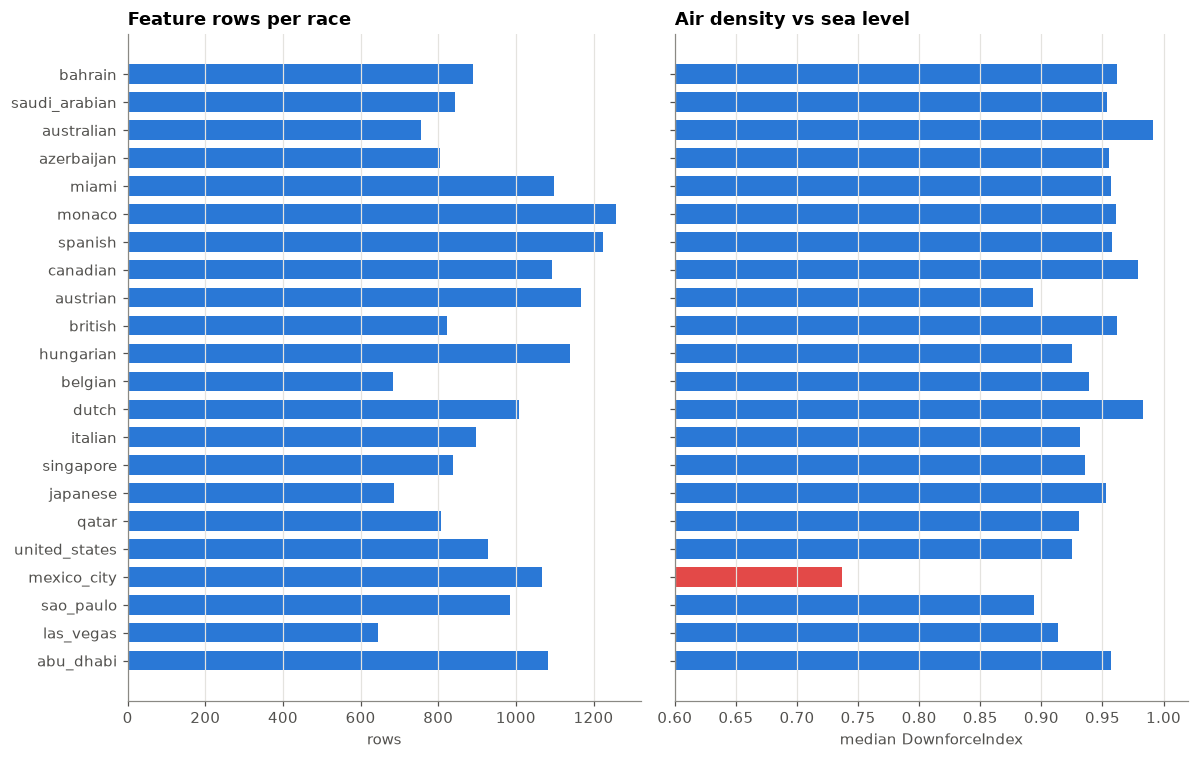

In [35]:
labels = summary["RaceId"].str.removeprefix(f"{YEAR}_")
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(11, 7))
axes[0].barh(labels, summary["rows"], color=GAIN, height=0.7)
axes[0].set_title("Feature rows per race", loc="left"); axes[0].set_xlabel("rows")
is_low = summary["downforce_idx"] < 0.85
axes[1].barh(labels, summary["downforce_idx"], color=np.where(is_low, LOSS, GAIN), height=0.7)
axes[1].set_xlim(0.6, 1.02); axes[1].set_xlabel("median DownforceIndex")
axes[1].set_title("Air density vs sea level", loc="left")
axes[0].invert_yaxis()
for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout()

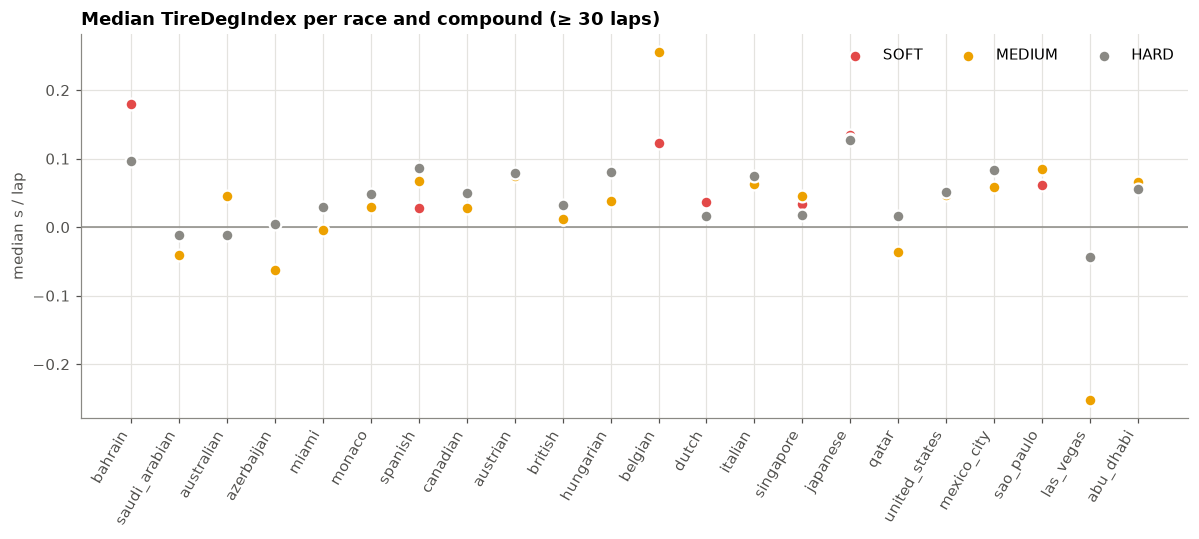

In [36]:
# Median degradation index per race and compound: which tracks eat tyres?
deg_by = (season.dropna(subset=["TireDegIndex_s_per_lap"])
                .groupby(["Round", "RaceId", "Compound"], observed=True)["TireDegIndex_s_per_lap"]
                .agg(["median", "size"]).reset_index())
deg_by = deg_by[deg_by["size"] >= 30]  # skip compounds barely used at a race

fig, ax = plt.subplots(figsize=(11, 5))
for comp, color in COMPOUND_COLORS.items():
    d = deg_by[deg_by["Compound"] == comp]
    ax.scatter(d["Round"], d["median"], s=60, color=color, edgecolor="white", linewidth=1.5, label=comp, zorder=3)
ax.axhline(0, color=NEUTRAL, linewidth=1)
ticks = summary.drop_duplicates("Round")
ax.set_xticks(ticks["Round"], ticks["RaceId"].str.removeprefix(f"{YEAR}_"), rotation=60, ha="right")
ax.set_ylabel("median s / lap"); ax.legend(ncol=3)
ax.set_title("Median TireDegIndex per race and compound (≥ 30 laps)", loc="left")
plt.tight_layout()